# 02 — Model Evaluation EDA
**Purpose:** Compare all three modelling approaches and validate model health.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 110})

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
REAL_M = [9, 10, 11]

FINAL_PATH = Path('../data/processed/final.csv')
MODEL_PATH = Path('../models/best_solar_pipeline.pkl')

df = pd.read_csv(FINAL_PATH)
print(f"Loaded: {len(df):,} records  |  {df.shape[1]} columns")
print(f"Accounts: {df['ACCOUNT_NO'].nunique()}")
df.head()

Loaded: 2,991 records  |  19 columns
Accounts: 251


,ACCOUNT_NO,Month,EXPORT_kWh,INV_CAPACITY,Solar_Irradiance_GHI,Temperature,Humidity,Precipitation,Wind_Speed,Temp_Efficiency,Temp_Range,GHI_Adjusted,Cloud_Factor,Month_Sin,Month_Cos,Days_In_Month,Expected_Generation,Physics_Pred,Efficiency
0,703376806,1,280.75,5.0,5.6150,25.07,78.30,1.03,3.92,1.000,10.72,5.62,0.91,0.500,0.866,31,696.26,139.25,56.150
1,703376806,2,355.69,5.0,6.4942,26.47,75.66,2.40,2.92,0.993,11.70,6.45,0.95,0.866,0.500,28,727.35,145.47,71.138
2,703376806,3,362.02,5.0,5.9909,27.42,76.90,3.98,2.33,0.988,9.15,5.92,0.85,1.000,0.000,31,742.87,148.57,72.404
3,703376806,4,294.76,5.0,5.9580,27.70,80.60,8.83,2.23,0.986,8.86,5.87,0.84,0.866,-0.500,30,714.96,142.99,58.952
4,703376806,5,296.40,5.0,4.5674,26.95,87.01,13.33,4.45,0.990,6.33,4.52,0.67,0.500,-0.866,31,566.36,113.27,59.280


## 1. Generate Predictions — All Three Approaches

In [2]:
import sys
sys.path.insert(0, str(Path('../').resolve()))
from src.features.selection import get_model_features, get_column_config
from src.features.selection import MODEL_FEATURES

# -- Household split (same seed as training) --------------------
X = df[MODEL_FEATURES]
y = df['Efficiency']
groups = df['ACCOUNT_NO']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
df_test         = df.iloc[test_idx]
df_train        = df.iloc[train_idx]

print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")

# -- 1. Physics baseline ----------------------------------------
pred_physics = df_test['Physics_Pred'].values

# -- 2. Similarity matching -------------------------------------
SIM_FEATURES = ['Solar_Irradiance_GHI', 'Temperature', 'Cloud_Factor']
scaler_sim   = StandardScaler()
X_train_sim  = scaler_sim.fit_transform(df_train[SIM_FEATURES])
X_test_sim   = scaler_sim.transform(df_test[SIM_FEATURES])
nn = NearestNeighbors(n_neighbors=3, metric='euclidean')
nn.fit(X_train_sim)
_, indices = nn.kneighbors(X_test_sim)
pred_sim = np.array([y_train.values[idx].mean() for idx in indices])

# -- 3. Best ML model -------------------------------------------
ml_pipe    = joblib.load(MODEL_PATH)
pred_ml    = ml_pipe.predict(X_test)

# -- Metrics ----------------------------------------------------
results = []
for name, preds in [('Physics Formula', pred_physics),
                    ('Similarity Match', pred_sim),
                    ('Best ML Model',   pred_ml)]:
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test.values - preds) /
                          np.where(y_test.values==0, np.nan, y_test.values))) * 100
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE%': mape})
    print(f"{name:<20}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  MAPE={mape:.1f}%")

results_df = pd.DataFrame(results)

# Compute improvements
phys_mae = results_df.loc[results_df['Model']=='Physics Formula','MAE'].values[0]
sim_mae  = results_df.loc[results_df['Model']=='Similarity Match','MAE'].values[0]
ml_mae   = results_df.loc[results_df['Model']=='Best ML Model','MAE'].values[0]
print(f"\nML improvement over Physics   : {(phys_mae-ml_mae)/phys_mae*100:.1f}%")
print(f"ML improvement over Similarity: {(sim_mae-ml_mae)/sim_mae*100:.1f}%")

Train : 2,382  |  Test : 609
Physics Formula       MAE=66.489  RMSE=74.044  R²=-1.461  MAPE=159.0%
Similarity Match      MAE=39.589  RMSE=50.956  R²=-0.166  MAPE=72.2%
Best ML Model         MAE=18.335  RMSE=24.468  R²=0.731  MAPE=29.8%

ML improvement over Physics   : 72.4%
ML improvement over Similarity: 53.7%


## 2. Hierarchy of Models — MAE Bar Chart

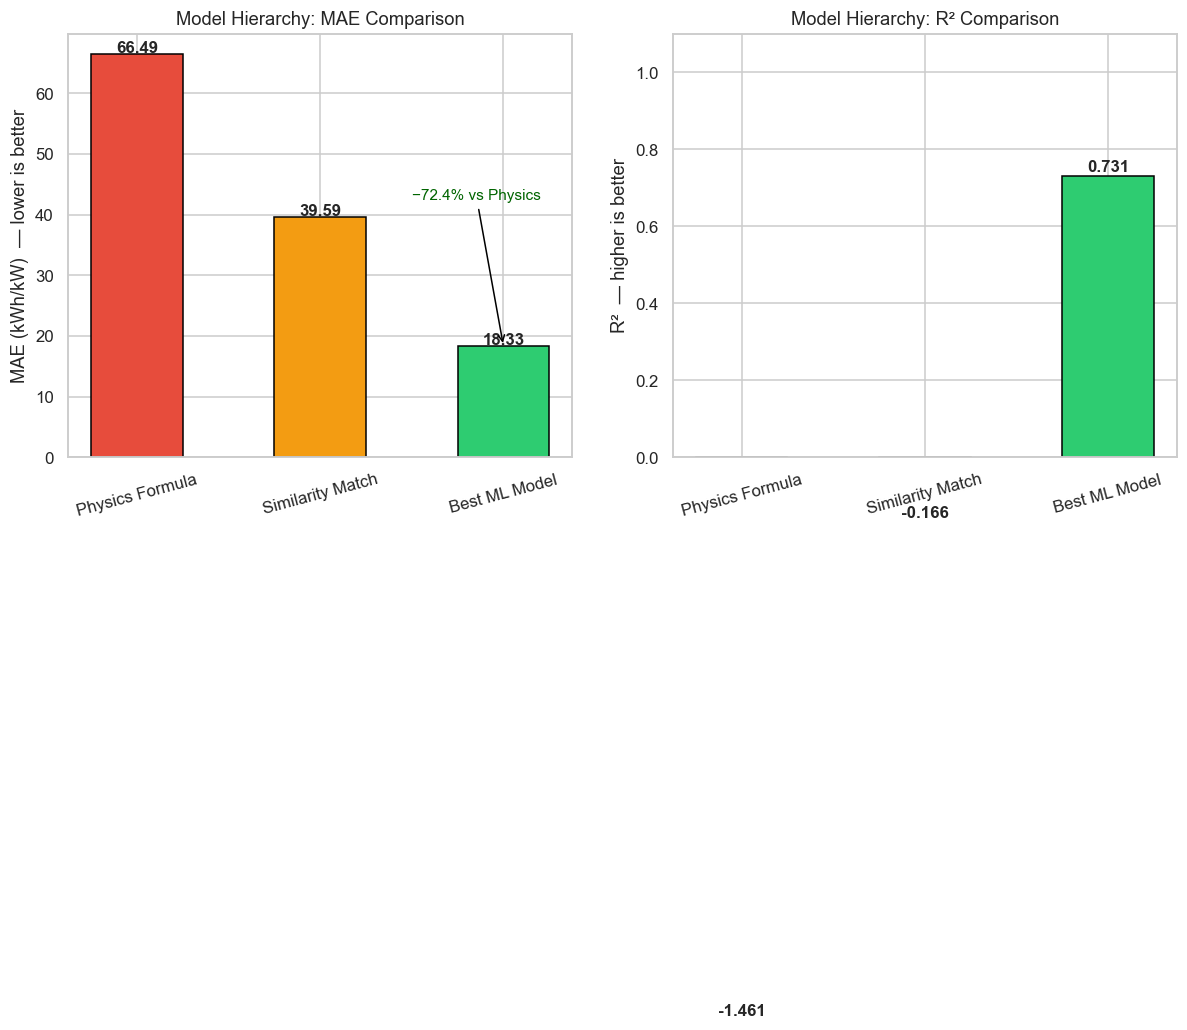

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MAE bar chart
colors  = ['#e74c3c', '#f39c12', '#2ecc71']
bars    = axes[0].bar(results_df['Model'], results_df['MAE'],
                      color=colors, edgecolor='black', width=0.5)
for bar, mae in zip(bars, results_df['MAE']):
    axes[0].text(bar.get_x()+bar.get_width()/2, mae+0.3,
                 f'{mae:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('MAE (kWh/kW)  — lower is better')
axes[0].set_title('Model Hierarchy: MAE Comparison')
axes[0].tick_params(axis='x', rotation=15)

# Annotate improvement arrows
y_phys = results_df.loc[0,'MAE']
y_ml   = results_df.loc[2,'MAE']
axes[0].annotate(
    f"−{(y_phys-y_ml)/y_phys*100:.1f}% vs Physics",
    xy=(2, y_ml), xytext=(1.5, (y_phys+y_ml)/2),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, color='darkgreen'
)

# R² comparison
bars2 = axes[1].bar(results_df['Model'], results_df['R²'],
                    color=colors, edgecolor='black', width=0.5)
for bar, r2 in zip(bars2, results_df['R²']):
    axes[1].text(bar.get_x()+bar.get_width()/2, r2+0.01,
                 f'{r2:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('R²  — higher is better')
axes[1].set_title('Model Hierarchy: R² Comparison')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('figures/02_model_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Actual vs Predicted — Test Set

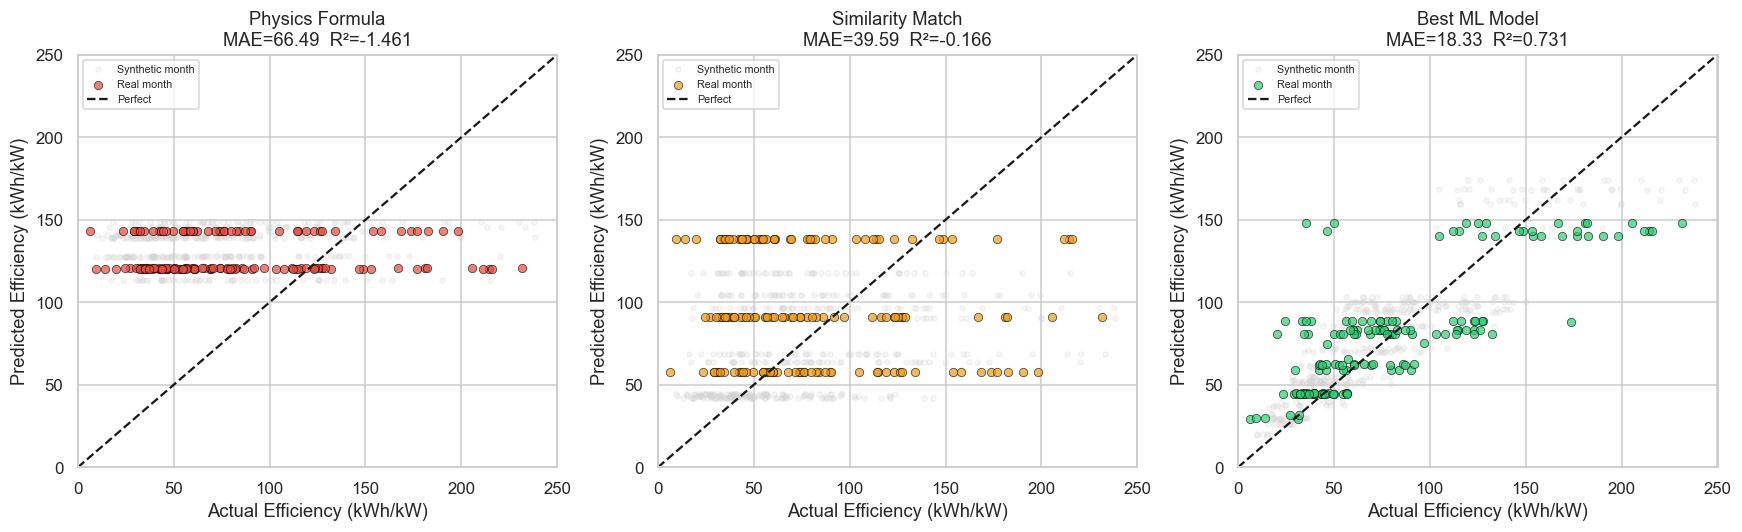

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Physics Formula', 'Similarity Match', 'Best ML Model']
preds_all = [pred_physics, pred_sim, pred_ml]
colors_pt  = ['#e74c3c',    '#f39c12',          '#2ecc71']

lim = [0, max(y_test.max(), max(p.max() for p in preds_all)) * 1.05]

for ax, name, preds, col in zip(axes, titles, preds_all, colors_pt):
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    # colour points by month — real months highlighted
    real_mask = df_test['Month'].isin(REAL_M).values
    ax.scatter(y_test[~real_mask], preds[~real_mask], alpha=0.2, s=12,
               color='lightgray', label='Synthetic month')
    ax.scatter(y_test[real_mask],  preds[real_mask],  alpha=0.7, s=30,
               color=col, edgecolor='black', linewidth=0.5, label='Real month')
    ax.plot(lim, lim, 'k--', linewidth=1.5, label='Perfect')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual Efficiency (kWh/kW)')
    ax.set_ylabel('Predicted Efficiency (kWh/kW)')
    ax.set_title(f'{name}\nMAE={mae:.2f}  R²={r2:.3f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('figures/02_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Residual Analysis — Error EDA

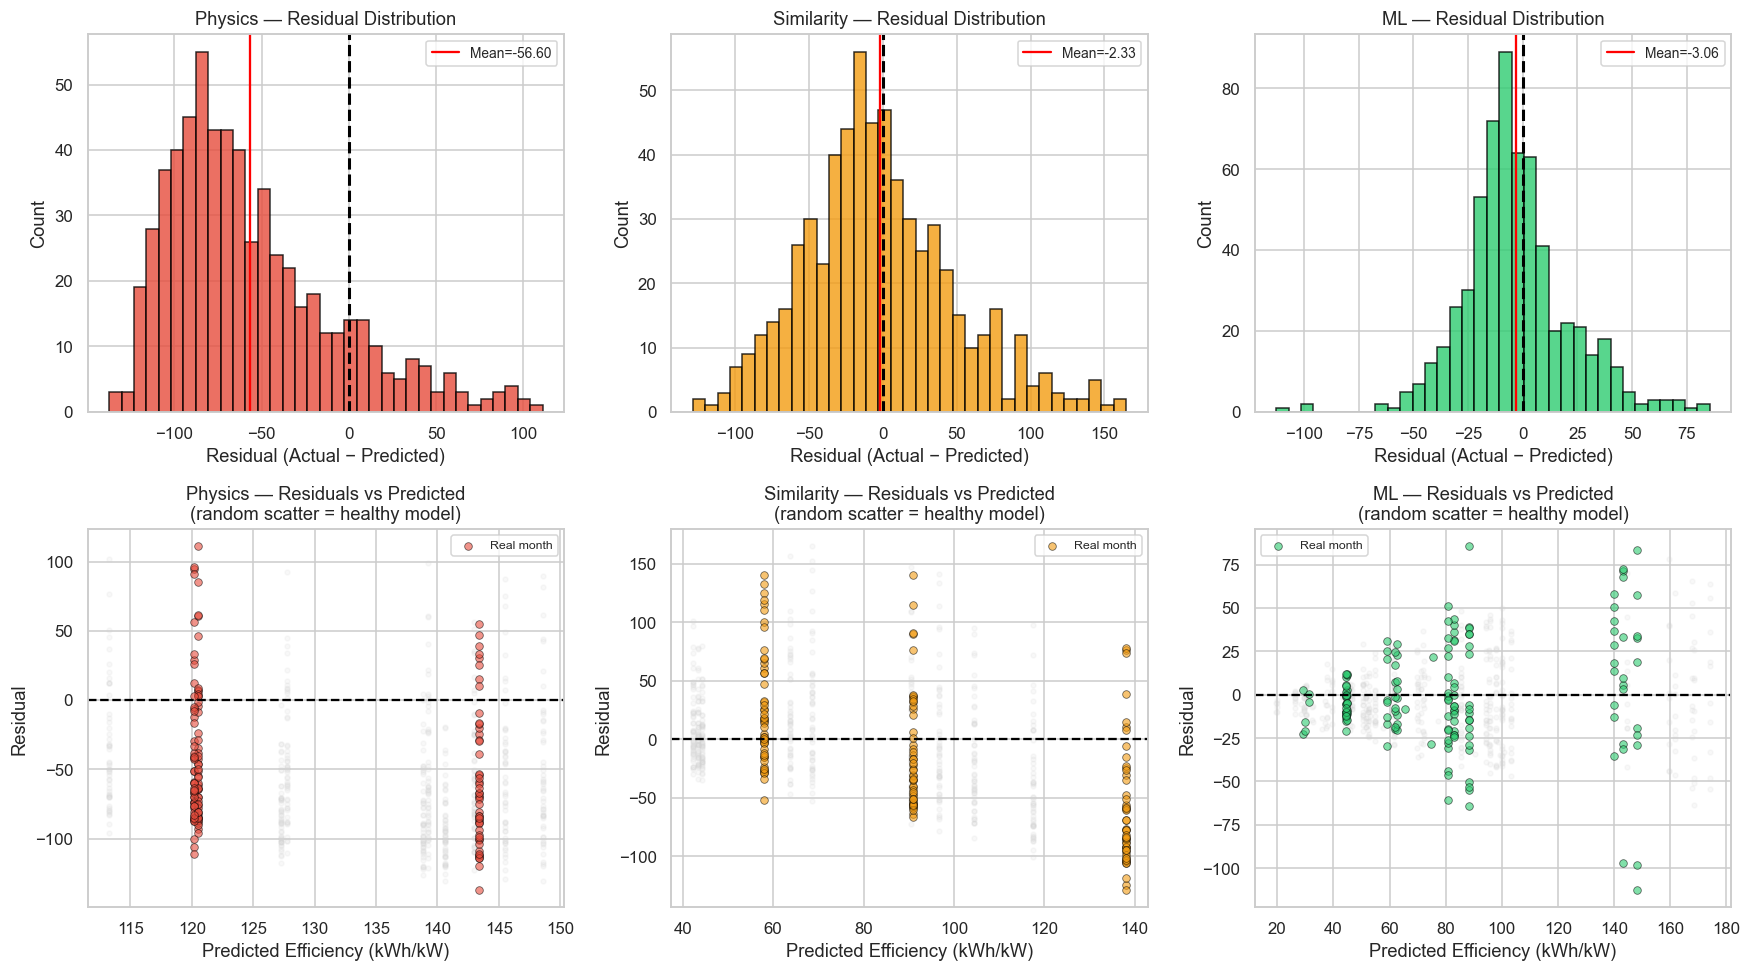

Residual mean (should be near 0 for unbiased model):
  Physics       : mean=-56.600  std=47.738
  Similarity    : mean=-2.332  std=50.902
  ML            : mean=-3.063  std=24.275


In [5]:
residuals_physics = y_test.values - pred_physics
residuals_sim     = y_test.values - pred_sim
residuals_ml      = y_test.values - pred_ml

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: Residual distributions
for ax, resid, name, col in zip(
    axes[0], [residuals_physics, residuals_sim, residuals_ml],
    ['Physics', 'Similarity', 'ML'], ['#e74c3c','#f39c12','#2ecc71']
):
    ax.hist(resid, bins=35, color=col, edgecolor='black', alpha=0.8)
    ax.axvline(0, color='black', linewidth=2, linestyle='--')
    ax.axvline(resid.mean(), color='red', linewidth=1.5,
               label=f'Mean={resid.mean():.2f}')
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Residual Distribution')
    ax.legend(fontsize=9)

# Row 2: Residuals vs predicted (pattern check)
for ax, preds, resid, name, col in zip(
    axes[1], [pred_physics, pred_sim, pred_ml],
    [residuals_physics, residuals_sim, residuals_ml],
    ['Physics', 'Similarity', 'ML'], ['#e74c3c','#f39c12','#2ecc71']
):
    real_mask = df_test['Month'].isin(REAL_M).values
    ax.scatter(preds[~real_mask], resid[~real_mask], alpha=0.15, s=10, color='lightgray')
    ax.scatter(preds[real_mask],  resid[real_mask],  alpha=0.6,  s=25, color=col,
               edgecolor='black', linewidth=0.5, label='Real month')
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted Efficiency (kWh/kW)')
    ax.set_ylabel('Residual')
    ax.set_title(f'{name} — Residuals vs Predicted\n(random scatter = healthy model)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/02_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Residual mean (should be near 0 for unbiased model):")
for name, resid in [('Physics',resid_p := residuals_physics),
                    ('Similarity',resid_s := residuals_sim),
                    ('ML',resid_m := residuals_ml)]:
    print(f"  {name:<14}: mean={resid.mean():.3f}  std={resid.std():.3f}")

## 5. Feature Importance — Best ML Model

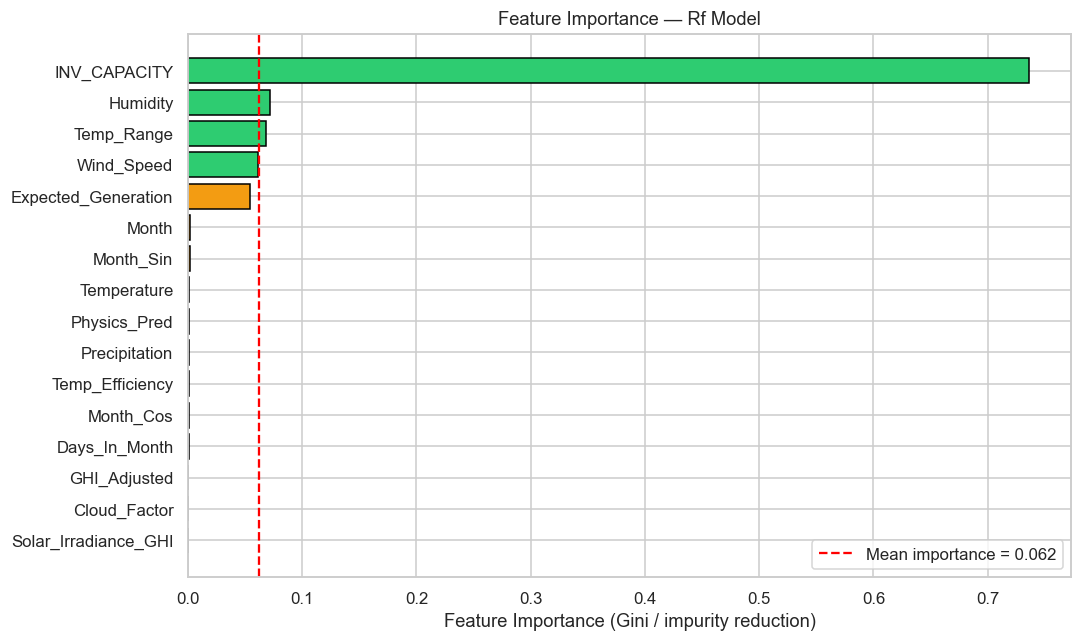

Top 5 features:
INV_CAPACITY           0.7365
Humidity               0.0720
Temp_Range             0.0680
Wind_Speed             0.0611
Expected_Generation    0.0540


In [6]:
# Works for tree-based models (RF, GB). Falls back gracefully for linear models.
step_name = [s for s in ml_pipe.named_steps if s != 'scaler'][0]
model     = ml_pipe.named_steps[step_name]

if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=MODEL_FEATURES)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    colors = ['#2ecc71' if v > importances.quantile(0.75) else
              '#f39c12' if v > importances.quantile(0.5) else '#aed6f1'
              for v in importances.values]
    plt.barh(importances.index, importances.values, color=colors, edgecolor='black')
    plt.axvline(importances.mean(), color='red', linestyle='--',
                label=f'Mean importance = {importances.mean():.3f}')
    plt.xlabel('Feature Importance (Gini / impurity reduction)')
    plt.title(f'Feature Importance — {step_name.title()} Model')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figures/02_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Top 5 features:")
    print(importances.sort_values(ascending=False).head(5).round(4).to_string())

elif hasattr(model, 'coef_'):
    coefs = pd.Series(np.abs(model.coef_), index=MODEL_FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(10,6))
    plt.barh(coefs.index, coefs.values, color='steelblue', edgecolor='black')
    plt.xlabel('|Coefficient|')
    plt.title(f'Feature Coefficients — {step_name.title()} Model')
    plt.tight_layout()
    plt.savefig('figures/02_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"{step_name} does not expose feature importances.")

## 6. Cross-Validation Stability — GroupKFold MAE per Fold

/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See h

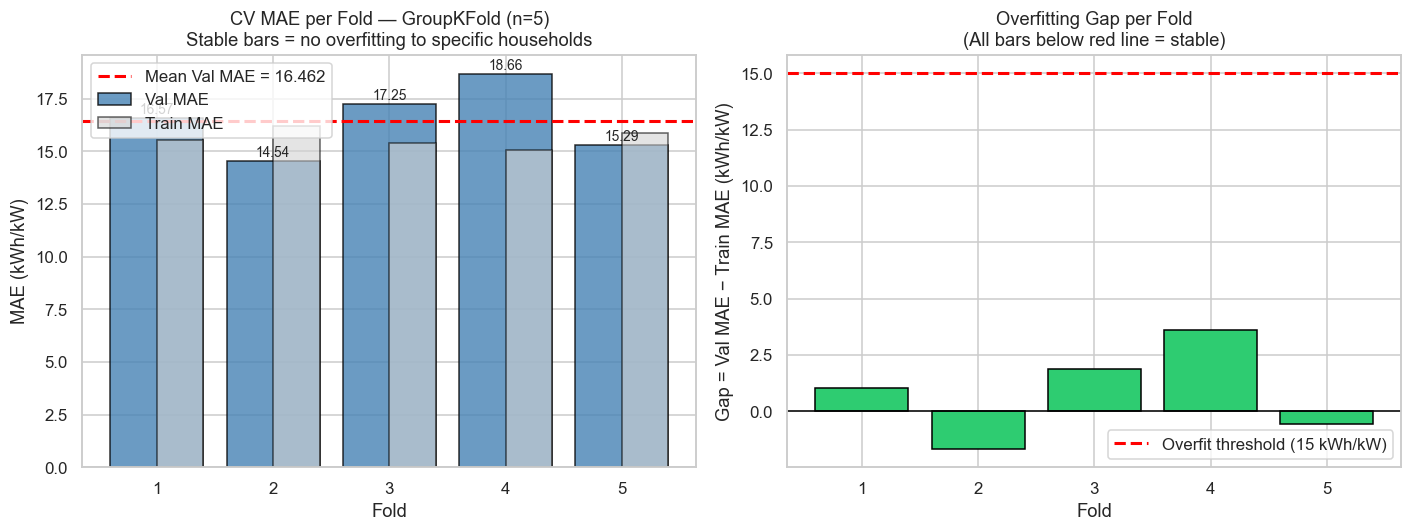

CV MAE per fold  : [16.568 14.542 17.249 18.66  15.29 ]
Mean CV MAE      : 16.462 ± 1.451 kWh/kW
Test MAE (final) : 18.335 kWh/kW
Max fold gap     : 3.613 kWh/kW  (stable ✓)


In [7]:
from sklearn.model_selection import GroupKFold, cross_validate

group_kfold = GroupKFold(n_splits=5)

cv_results = cross_validate(
    ml_pipe, X_train, y_train,
    cv=group_kfold.split(X_train, y_train, groups=groups.iloc[train_idx]),
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=-1,
)

cv_mae_test  = -cv_results['test_score']
cv_mae_train = -cv_results['train_score']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Per-fold MAE
folds = range(1, 6)
axes[0].bar(folds, cv_mae_test,  color='steelblue', edgecolor='black', alpha=0.8, label='Val MAE')
axes[0].bar(folds, cv_mae_train, color='lightgray', edgecolor='black', alpha=0.6, label='Train MAE', width=0.4,
            align='edge')
axes[0].axhline(cv_mae_test.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean Val MAE = {cv_mae_test.mean():.3f}')
for i, (tr, te) in enumerate(zip(cv_mae_train, cv_mae_test), 1):
    axes[0].text(i, te + 0.2, f'{te:.2f}', ha='center', fontsize=9)
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('MAE (kWh/kW)')
axes[0].set_title('CV MAE per Fold — GroupKFold (n=5)\nStable bars = no overfitting to specific households')
axes[0].legend()

# Train vs Val gap (overfitting visualisation)
gap = cv_mae_test - cv_mae_train
bar_colors = ['#e74c3c' if g > 15 else '#2ecc71' for g in gap]
axes[1].bar(folds, gap, color=bar_colors, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axhline(15, color='red', linestyle='--', linewidth=2, label='Overfit threshold (15 kWh/kW)')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Gap = Val MAE − Train MAE (kWh/kW)')
axes[1].set_title('Overfitting Gap per Fold\n(All bars below red line = stable)')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/02_cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"CV MAE per fold  : {np.round(cv_mae_test, 3)}")
print(f"Mean CV MAE      : {cv_mae_test.mean():.3f} ± {cv_mae_test.std():.3f} kWh/kW")
print(f"Test MAE (final) : {mean_absolute_error(y_test, pred_ml):.3f} kWh/kW")
print(f"Max fold gap     : {gap.max():.3f} kWh/kW  ({'OVERFIT' if gap.max()>15 else 'stable ✓'})")

## 7. Prediction Intervals — Forecast with Uncertainty Bands

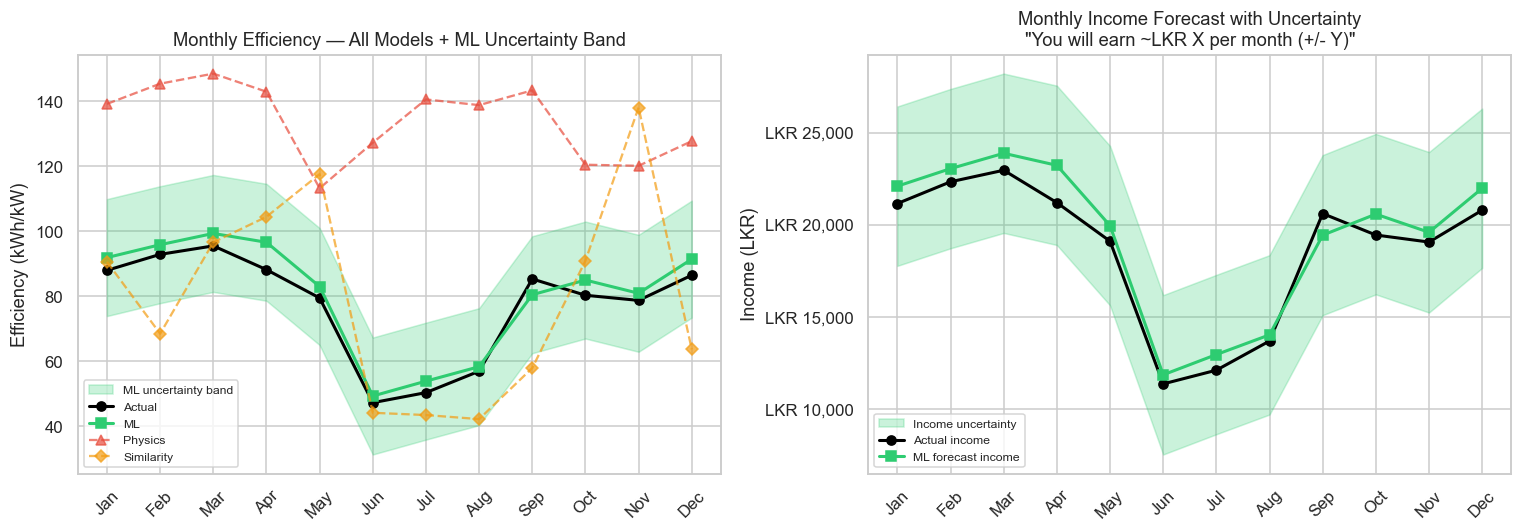

Annual ML income forecast : LKR 232,539
Uncertainty band          : LKR 180,557 to LKR 284,521
Margin                    : +/- LKR 51,982


In [8]:
# Forecast shown as a shaded band (prediction ± MAE).
# Left panel: Efficiency (kWh/kW) — all three models on the same axes.
# Right panel: Monthly income (LKR) — what the end user actually cares about.

import sys
sys.path.insert(0, str(Path('../../').resolve()))
from utils.utils_config import load_config
cfg        = load_config()
mae_per_kw = cfg['roi']['mae_kwh_per_kw']
tariff     = cfg['roi']['net_plus_tariff_lkr']

test_months = df_test.copy()
test_months['pred_ml']      = pred_ml
test_months['pred_physics'] = pred_physics
test_months['pred_sim']     = pred_sim

ms = test_months.groupby('Month').agg(
    actual_mean   =('Efficiency','mean'),
    ml_mean       =('pred_ml','mean'),
    physics_mean  =('pred_physics','mean'),
    sim_mean      =('pred_sim','mean'),
    inv_cap_mean  =('INV_CAPACITY','mean'),
).reset_index()

for col in ['actual_mean','ml_mean','physics_mean','sim_mean']:
    ms[col+'_kwh'] = ms[col] * ms['inv_cap_mean']
mae_kwh = mae_per_kw * ms['inv_cap_mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
m = ms['Month']

ax = axes[0]
ax.fill_between(m, ms['ml_mean'] - mae_per_kw, ms['ml_mean'] + mae_per_kw,
                alpha=0.25, color='#2ecc71', label='ML uncertainty band')
ax.plot(m, ms['actual_mean'],  'o-', lw=2, color='black',   label='Actual')
ax.plot(m, ms['ml_mean'],      's-', lw=2, color='#2ecc71', label='ML')
ax.plot(m, ms['physics_mean'], '^--',lw=1.5, color='#e74c3c', alpha=0.7, label='Physics')
ax.plot(m, ms['sim_mean'],     'D--',lw=1.5, color='#f39c12', alpha=0.7, label='Similarity')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_ylabel('Efficiency (kWh/kW)')
ax.set_title('Monthly Efficiency — All Models + ML Uncertainty Band')
ax.legend(fontsize=8)

ax = axes[1]
ml_inc  = ms['ml_mean_kwh'] * tariff
lo_inc  = (ms['ml_mean_kwh'] - mae_kwh) * tariff
hi_inc  = (ms['ml_mean_kwh'] + mae_kwh) * tariff
act_inc = ms['actual_mean_kwh'] * tariff
ax.fill_between(m, lo_inc, hi_inc, alpha=0.25, color='#2ecc71', label='Income uncertainty')
ax.plot(m, act_inc, 'o-', lw=2, color='black',   label='Actual income')
ax.plot(m, ml_inc,  's-', lw=2, color='#2ecc71', label='ML forecast income')
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS, rotation=45)
ax.set_ylabel('Income (LKR)')
ax.set_title('Monthly Income Forecast with Uncertainty\n"You will earn ~LKR X per month (+/- Y)"')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'LKR {x:,.0f}'))
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/02_prediction_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

ann_ml, ann_lo, ann_hi = ml_inc.sum(), lo_inc.sum(), hi_inc.sum()
print(f'Annual ML income forecast : LKR {ann_ml:,.0f}')
print(f'Uncertainty band          : LKR {ann_lo:,.0f} to LKR {ann_hi:,.0f}')
print(f'Margin                    : +/- LKR {(ann_hi-ann_lo)/2:,.0f}')


## 8. Comparison Table — Thesis Results Summary

In [18]:
# Rendered HTML table for notebook viewing + plain text for thesis / LaTeX.
from IPython.display import display, HTML

approach_map = {
    'Physics Formula' : ('Deterministic',   'GHI x 0.80 x Days -- no historical data needed'),
    'Similarity Match': ('Statistical',      'k=3 nearest historical months by GHI/Temp/Cloud'),
    'Best ML Model'   : ('Machine Learning', 'Tuned ensemble -- non-linear feature weights'),
}

phys_mae = results_df.loc[results_df['Model']=='Physics Formula', 'MAE'].values[0]

header = (
    '<table style="border-collapse:collapse;width:100%;font-family:Arial;font-size:13px">'
    '<tr style="background:#2c3e50;color:white">'
    '<th style="padding:8px">Model</th>'
    '<th style="padding:8px">Approach</th>'
    '<th style="padding:8px">MAE (kWh/kW)</th>'
    '<th style="padding:8px">RMSE</th>'
    '<th style="padding:8px">R2</th>'
    '<th style="padding:8px">MAPE</th>'
    '<th style="padding:8px">vs Physics</th>'
    '<th style="padding:8px">Logic</th>'
    '</tr>'
)
rows = ''
bg_map = {
    'Physics Formula':'#f8c8c8',    # light coral
    'Similarity Match':'#fff1a8',    # light goldenrod
    'Best ML Model':'#bfffc0'        # light mint green
}
for _, row in results_df.iterrows():
    approach, logic = approach_map[row['Model']]
    pct = f'+{(phys_mae - row["MAE"])/phys_mae*100:.1f}%' if row['Model'] != 'Physics Formula' else 'baseline'
    bg  = bg_map.get(row['Model'], 'white')
    rows += (
        f'<tr style="background:{bg}">'
        f'<td style="padding:7px; color:black"><b>{row["Model"]}</b></td>'
        f'<td style="padding:7px; color:black">{approach}</td>'
        f'<td style="padding:7px; color:black">{row["MAE"]:.3f}</td>'
        f'<td style="padding:7px; color:black">{row["RMSE"]:.3f}</td>'
        f'<td style="padding:7px; color:black">{row["R²"]:.3f}</td>'
        f'<td style="padding:7px; color:black">{row["MAPE%"]:.1f}%</td>'
        f'<td style="padding:7px; color:darkgreen">{pct}</td>'
        f'<td style="padding:7px; color:black; font-size:11px">{logic}</td>'
        '</tr>'
    )
display(HTML(header + rows + '</table>'))

print('\nPlain-text (for LaTeX / Word):')
print(f'{"Model":<20} {"Approach":<16} {"MAE":>7} {"RMSE":>7} {"R²":>7} {"MAPE":>7}  vs Physics')
print('-'*78)
for _, row in results_df.iterrows():
    approach, _ = approach_map[row['Model']]
    pct = f'+{(phys_mae-row["MAE"])/phys_mae*100:.1f}%' if row['Model']!='Physics Formula' else 'baseline'
    print(f'{row["Model"]:<20} {approach:<16} {row["MAE"]:>7.3f} {row["RMSE"]:>7.3f} '
          f'{row["R²"]:>7.3f} {row["MAPE%"]:>6.1f}%  {pct}')


Model,Approach,MAE (kWh/kW),RMSE,R2,MAPE,vs Physics,Logic
Physics Formula,Deterministic,66.489,74.044,-1.461,159.0%,baseline,GHI x 0.80 x Days -- no historical data needed
Similarity Match,Statistical,39.589,50.956,-0.166,72.2%,+40.5%,k=3 nearest historical months by GHI/Temp/Cloud
Best ML Model,Machine Learning,18.335,24.468,0.731,29.8%,+72.4%,Tuned ensemble -- non-linear feature weights



Plain-text (for LaTeX / Word):
Model                Approach             MAE    RMSE      R²    MAPE  vs Physics
------------------------------------------------------------------------------
Physics Formula      Deterministic     66.489  74.044  -1.461  159.0%  baseline
Similarity Match     Statistical       39.589  50.956  -0.166   72.2%  +40.5%
Best ML Model        Machine Learning  18.335  24.468   0.731   29.8%  +72.4%


## 9. Efficiency Distribution by Month — Seasonal Justification

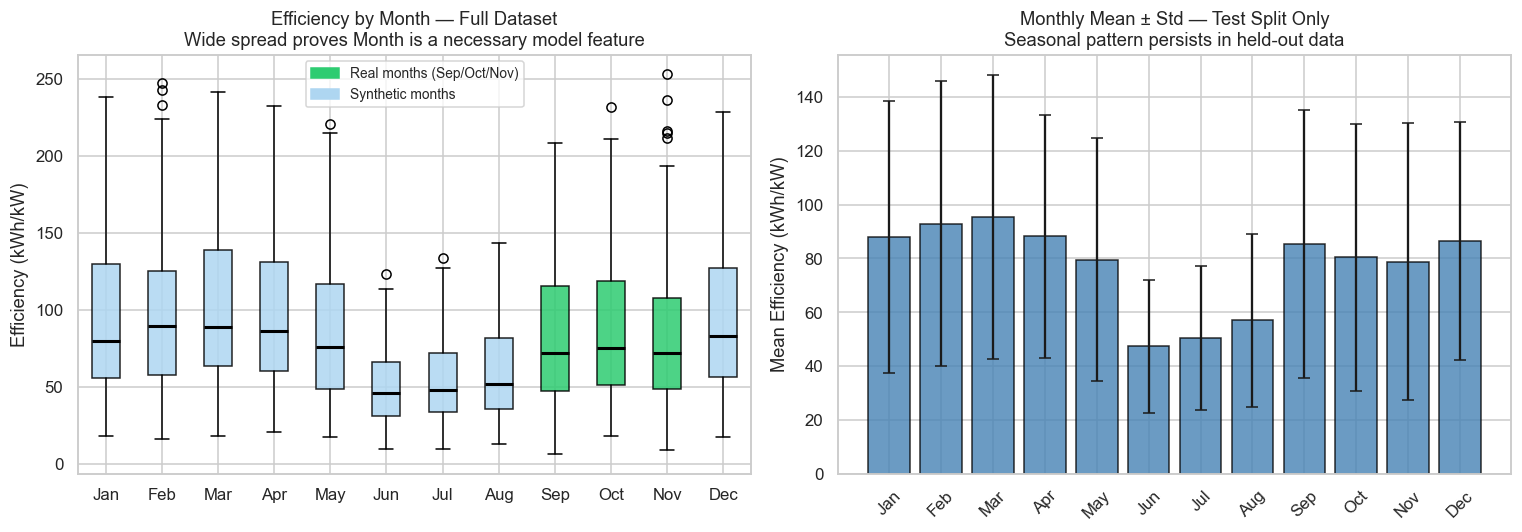

Range across months : 50.7 to 102.9 kWh/kW
Spread              : 52.2 kWh/kW (63.0% of overall mean)
Omitting Month as a feature would lose this seasonal information.


In [10]:
# Boxplot showing variance of Efficiency per month.
# Wide spread between months = Month feature carries real predictive signal.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
real_m_set = {9, 10, 11}

monthly_data = [df[df['Month']==m]['Efficiency'].values for m in range(1,13)]
bp = axes[0].boxplot(monthly_data, labels=MONTHS, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], range(1,13)):
    patch.set_facecolor('#2ecc71' if m in real_m_set else '#aed6f1')
    patch.set_alpha(0.85)
axes[0].set_ylabel('Efficiency (kWh/kW)')
axes[0].set_title('Efficiency by Month — Full Dataset\n'
                  'Wide spread proves Month is a necessary model feature')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#2ecc71', label='Real months (Sep/Oct/Nov)'),
    Patch(color='#aed6f1', label='Synthetic months')
], fontsize=9)

# Right: test split monthly mean ± std
tm = df_test.groupby('Month')['Efficiency'].agg(['mean','std'])
axes[1].bar(tm.index, tm['mean'], yerr=tm['std'], color='steelblue',
            edgecolor='black', alpha=0.8, capsize=4)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(MONTHS, rotation=45)
axes[1].set_ylabel('Mean Efficiency (kWh/kW)')
axes[1].set_title('Monthly Mean ± Std — Test Split Only\n'
                  'Seasonal pattern persists in held-out data')

plt.tight_layout()
plt.savefig('figures/02_efficiency_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

means = df.groupby('Month')['Efficiency'].mean()
rng   = means.max() - means.min()
print(f'Range across months : {means.min():.1f} to {means.max():.1f} kWh/kW')
print(f'Spread              : {rng:.1f} kWh/kW ({rng/means.mean()*100:.1f}% of overall mean)')
print('Omitting Month as a feature would lose this seasonal information.')


## 10. Case Study — One Account: 12-Month Actual vs Predicted

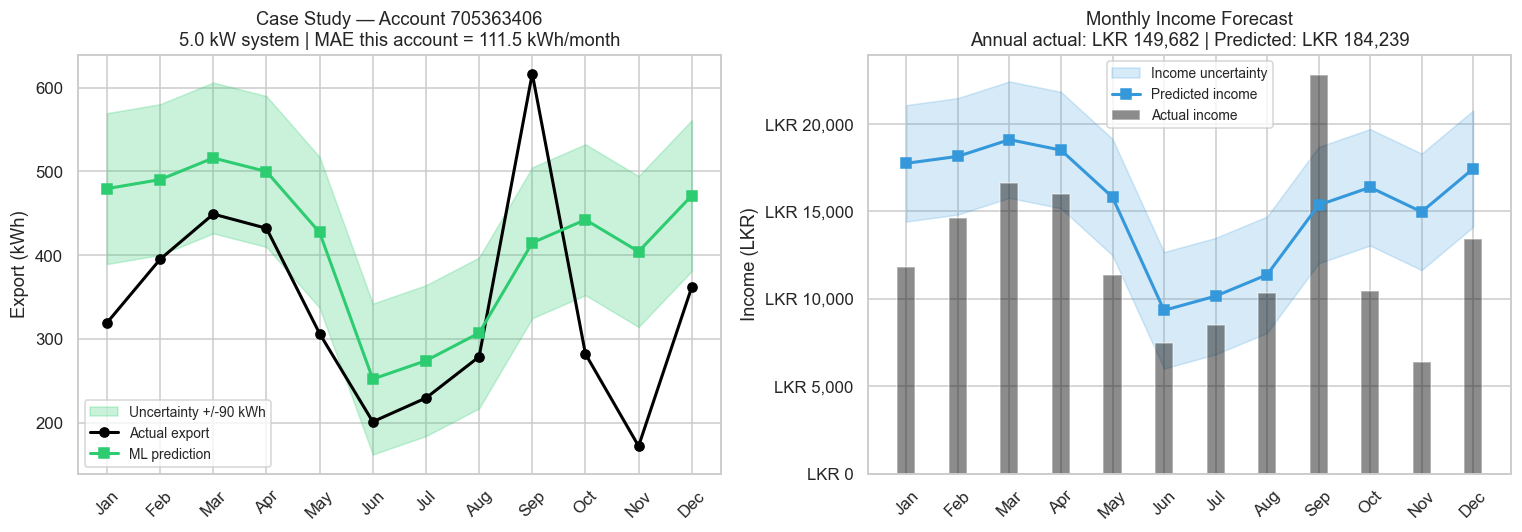

System size   : 5.0 kW
MAE per month : 111.5 kWh  |  LKR 4,125
Annual actual : 4045 kWh  |  LKR 149,682
Annual pred   : 4979 kWh  |  LKR 184,239
Annual error  : 934 kWh  |  LKR 34,557


In [11]:
# Pick the test-set account closest to median annual Efficiency
# (the 'typical' household — not the best or worst case).
# Plot 12 months of actual vs ML prediction + income with uncertainty band.

mae_pw = cfg['roi']['mae_kwh_per_kw']

test_copy = df_test.copy()
test_copy['pred_ml'] = pred_ml

acc_median    = test_copy.groupby('ACCOUNT_NO')['Efficiency'].mean()
target_med    = acc_median.median()
case_account  = (acc_median - target_med).abs().idxmin()
case_df       = test_copy[test_copy['ACCOUNT_NO']==case_account].sort_values('Month')

inv_cap    = case_df['INV_CAPACITY'].iloc[0]
mae_kwh    = mae_pw * inv_cap

actual_kwh = case_df['Efficiency'].values * inv_cap
pred_kwh   = case_df['pred_ml'].values    * inv_cap
lo_kwh     = (pred_kwh - mae_kwh).clip(min=0)
hi_kwh     = pred_kwh + mae_kwh
m_labels   = [MONTHS[int(m)-1] for m in case_df['Month']]
x          = range(len(case_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Export kWh
ax = axes[0]
ax.fill_between(x, lo_kwh, hi_kwh, alpha=0.25, color='#2ecc71',
                label=f'Uncertainty +/-{mae_kwh:.0f} kWh')
ax.plot(x, actual_kwh, 'o-', lw=2, color='black',   label='Actual export')
ax.plot(x, pred_kwh,   's-', lw=2, color='#2ecc71', label='ML prediction')
ax.set_xticks(x); ax.set_xticklabels(m_labels, rotation=45)
ax.set_ylabel('Export (kWh)')
case_mae = abs(actual_kwh - pred_kwh).mean()
ax.set_title(f'Case Study — Account {case_account}\n'
             f'{inv_cap} kW system | MAE this account = {case_mae:.1f} kWh/month')
ax.legend(fontsize=9)

# Right: Monthly income (LKR)
ax = axes[1]
actual_inc = actual_kwh * tariff
pred_inc   = pred_kwh   * tariff
lo_inc     = lo_kwh     * tariff
hi_inc     = hi_kwh     * tariff
ax.fill_between(x, lo_inc, hi_inc, alpha=0.2, color='#3498db', label='Income uncertainty')
ax.bar(x, actual_inc, alpha=0.45, color='black',   width=0.35, label='Actual income',     align='center')
ax.plot(x, pred_inc, 's-', lw=2, color='#3498db', label='Predicted income')
ax.set_xticks(x); ax.set_xticklabels(m_labels, rotation=45)
ax.set_ylabel('Income (LKR)')
ax.set_title(f'Monthly Income Forecast\n'
             f'Annual actual: LKR {actual_inc.sum():,.0f} | Predicted: LKR {pred_inc.sum():,.0f}')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'LKR {v:,.0f}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/02_case_study.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'System size   : {inv_cap} kW')
print(f'MAE per month : {case_mae:.1f} kWh  |  LKR {case_mae*tariff:,.0f}')
print(f'Annual actual : {actual_kwh.sum():.0f} kWh  |  LKR {actual_inc.sum():,.0f}')
print(f'Annual pred   : {pred_kwh.sum():.0f} kWh  |  LKR {pred_inc.sum():,.0f}')
print(f'Annual error  : {abs(actual_kwh.sum()-pred_kwh.sum()):.0f} kWh  |  LKR {abs(actual_inc.sum()-pred_inc.sum()):,.0f}')
